# Финансовая модель эффекта: накопительный счёт

Расчёт эффекта проекта по каркасу «изменение показателя × объём × стоимость
единицы» с разворачиванием во времени: выход на уровень, срок сохранения,
затраты, окупаемость, чистая приведённая стоимость и проверка
чувствительности. Множители, которые есть в данных, считаются из выгрузки;
остальные записаны как допущения с диапазонами.

Кейс: инструмент корреляций показал согласованное изменение закрытий
и жалоб по месячным итогам; гипотеза проекта — ускоренный разбор обращений
предотвращает часть закрытий. Теория расчёта — страница «Финансовая модель
проекта» в материалах курса; тот же расчёт без кода — тренажёр «Финансовая
модель эффекта».

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
ЗЕЛ, ТЁМН, КРАСН = '#20BA72', '#2E3641', '#D2564A'

def руб(x):
    a = abs(x)
    if a >= 1e6:
        return f'{x/1e6:,.2f}'.replace(',', ' ').replace('.', ',') + ' млн руб.'
    if a >= 1e4:
        return f'{x/1e3:,.0f} тыс. руб.'.replace(',', ' ')
    return f'{x:,.0f} руб.'.replace(',', ' ')

## 1. Множители из данных

Выгрузка по месяцам, регионам и каналам. Для модели нужны два числа:
сколько счетов закрывается в месяц (объём, к которому применяется гипотеза)
и средний остаток на счёте (основа стоимости единицы).

In [2]:
d = pd.read_csv('../data/product/savings_monthly.csv', sep=';', decimal=',',
                encoding='utf-8-sig')
m = d.groupby('месяц').agg(закрытия=('закрытые_счета', 'sum'),
                          открытия=('новые_счета', 'sum'),
                          жалобы=('жалобы', 'sum'),
                          средний_остаток=('средний_остаток_тыс_руб', 'mean'))
последние = m.tail(12)
закрытий_в_месяц = последние['закрытия'].mean()
жалоб_в_месяц = последние['жалобы'].mean()
остаток_тыс = последние['средний_остаток'].mean()
print(f'Закрытий в месяц (среднее за последние 12 мес.): {закрытий_в_месяц:,.0f}'.replace(',', ' '))
print(f'Жалоб в месяц: {жалоб_в_месяц:,.0f}')
print(f'Средний остаток на счёте: {остаток_тыс:.1f} тыс. руб.'.replace('.', ','))
m.tail(12)

Закрытий в месяц (среднее за последние 12 мес.): 1 854
Жалоб в месяц: 260
Средний остаток на счёте: 221,3 тыс, руб,


,закрытия,открытия,жалобы,средний_остаток
месяц,,,,
2025-07,1430,5686,215,216.785
2025-08,1548,6080,230,220.925
2025-09,1699,6385,232,216.125
2025-10,1711,6871,228,220.585
2025-11,1922,7606,261,218.580
2025-12,1999,7491,295,219.215
2026-01,2008,7540,268,221.180
2026-02,2030,7624,273,219.320
2026-03,2045,7108,295,225.560


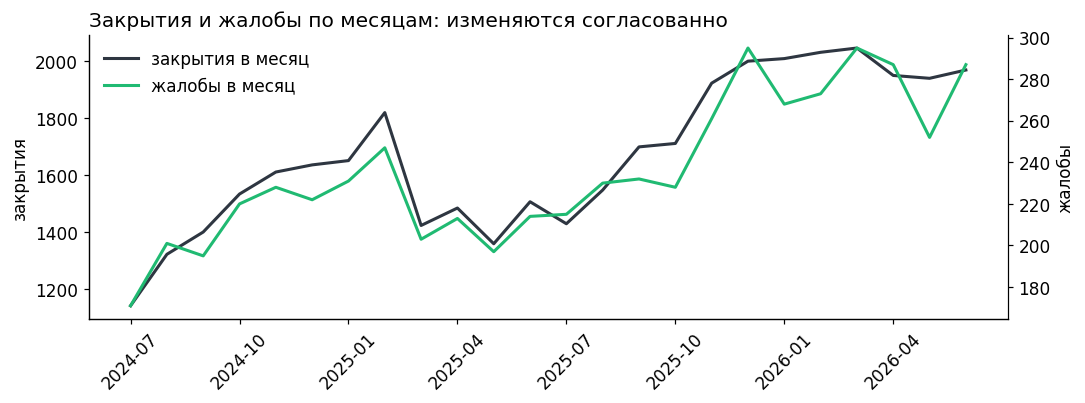

Корреляция закрытий и жалоб по месячным итогам: 0.96


In [3]:
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(m.index, m['закрытия'], color=ТЁМН, lw=2, label='закрытия в месяц')
ax2 = ax.twinx(); ax2.spines['right'].set_visible(True)
ax2.plot(m.index, m['жалобы'], color=ЗЕЛ, lw=2, label='жалобы в месяц')
ax.set_xticks(m.index[::3]); ax.tick_params(axis='x', rotation=45)
ax.set_ylabel('закрытия'); ax2.set_ylabel('жалобы')
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', frameon=False)
ax.set_title('Закрытия и жалобы по месяцам: изменяются согласованно', loc='left')
plt.tight_layout(); plt.show()
print('Корреляция закрытий и жалоб по месячным итогам:',
      round(m['закрытия'].corr(m['жалобы']), 2))

## 2. Допущения

Всё, чего нет в данных, записывается как допущение: значение, единица,
источник, диапазон от пессимистичного до оптимистичного, чем подтверждается.
Доля предотвратимых закрытий — главное допущение проекта: до получения
структурированных причин закрытий её нельзя посчитать, только оценить.

In [4]:
маржа_пп = 3.0                       # п. п., справочная ставка казначейства — допущение
P = остаток_тыс * 1000 * маржа_пп / 100 / 12   # руб. маржи на счёт в месяц
доля_предотвратимых = 1/3            # допущение: треть закрытий, связанных с жалобами
связанных_с_жалобами = 300           # допущение: закрытий в месяц с неразобранным обращением
delta = связанных_с_жалобами * доля_предотвратимых   # предотвращённых закрытий в месяц

параметры = dict(
    kind='cohort',      # удержанные счета накапливаются по когортам
    delta=delta,        # предотвращённых закрытий в месяц
    volume=1,           # единица эффекта — один счёт
    price=round(P),     # руб. на счёт в месяц
    ramp=3,             # выход на уровень, мес. — допущение
    keep=12,            # срок сохранения удержанного счёта, мес. — допущение
    capex=600_000,      # доработка очереди обращений — допущение
    opex=50_000,        # дополнительные операторы в месяц — допущение
    horizon=24,         # горизонт расчёта, мес. — инвестиционные правила
    rate=0.15,          # ставка дисконтирования, годовая
)
допущения = [
    # ключ, название, базовое, пессимистичное, оптимистичное
    ('delta', 'Предотвращённых закрытий в месяц', параметры['delta'], 35, 130),
    ('price', 'Маржа на счёт в месяц, руб.', параметры['price'], 400, 650),
    ('keep',  'Срок сохранения счёта, мес.', 12, 4, 18),
    ('capex', 'Единовременные затраты, руб.', 600_000, 900_000, 450_000),
    ('opex',  'Ежемесячные затраты, руб.', 50_000, 80_000, 35_000),
]
print(f'Δ×V = {delta:.0f} удержанных счетов в месяц; P = {P:,.0f} руб. на счёт в месяц')
print(f'Эффект на полном уровне одной месячной когорты: {руб(delta * P)} в месяц')

Δ×V = 100 удержанных счетов в месяц; P = 553 руб. на счёт в месяц
Эффект на полном уровне одной месячной когорты: 55 тыс. руб. в месяц


## 3. Поток эффекта по месяцам

Каждый месяц появляется новая когорта удержанных счетов; каждая когорта
приносит `P` в месяц на счёт в течение `keep` месяцев; первые `ramp` месяцев
эффект выходит на уровень линейно. Месяц 0 — единовременные затраты,
каждый следующий месяц — ежемесячные. Формулы те же, что в тренажёре.

In [5]:
def поток(p):
    H, T, R = int(p['horizon']), p['ramp'], p['keep']
    полный = p['delta'] * p['volume']
    m_ = (1 + p['rate']) ** (1/12) - 1
    ramp = lambda t: 1.0 if T <= 0 else min(t / T, 1.0)
    строки, cum, cum_d = [], 0.0, 0.0
    for t in range(H + 1):
        if t == 0:
            units, доход, затраты = 0.0, 0.0, p['capex']
        else:
            затраты = p['opex']
            if p['kind'] == 'cohort':
                units = sum(полный * ramp(k) for k in range(max(1, t - R + 1), t + 1))
            else:
                units = полный * ramp(t) if t <= R else 0.0
            доход = units * p['price']
        cf = доход - затраты
        cum += cf; disc = cf / (1 + m_) ** t; cum_d += disc
        строки.append(dict(месяц=t, счетов=units, доход=доход, затраты=затраты,
                           поток=cf, накопленный=cum, дисконтированный=disc,
                           накопленный_с_дисконтом=cum_d))
    return pd.DataFrame(строки).set_index('месяц')

def итоги(p):
    f = поток(p)
    окуп = next((t for t in f.index if t > 0 and f.loc[t, 'накопленный'] >= 0), None)
    return dict(поток=f, NPV=f['накопленный_с_дисконтом'].iloc[-1],
                окупаемость=окуп, доход_год1=f.loc[1:12, 'доход'].sum())

r = итоги(параметры)
f = r['поток']
print(f"Доход за первый год: {руб(r['доход_год1'])}")
print(f"Окупаемость: месяц {r['окупаемость']}")
print(f"NPV за {параметры['horizon']} мес. при ставке {параметры['rate']:.0%}: {руб(r['NPV'])}")
f.loc[[0, 1, 2, 3, 6, 12, 18, 24]].round(0)

Доход за первый год: 3,67 млн руб.
Окупаемость: месяц 7
NPV за 24 мес. при ставке 15%: 8,09 млн руб.


,счетов,доход,затраты,поток,накопленный,дисконтированный,накопленный_с_дисконтом
месяц,,,,,,,
0,0.0,0.0,600000,-600000.0,-600000.0,-600000.0,-600000.0
1,33.0,18433.0,50000,-31567.0,-631567.0,-31201.0,-631201.0
2,100.0,55300.0,50000,5300.0,-626267.0,5178.0,-626023.0
3,200.0,110600.0,50000,60600.0,-565667.0,58519.0,-567504.0
6,500.0,276500.0,50000,226500.0,-52067.0,211212.0,-84152.0
12,1100.0,608300.0,50000,558300.0,2468233.0,485478.0,2162518.0
18,1200.0,663600.0,50000,613600.0,6131400.0,497552.0,5220796.0
24,1200.0,663600.0,50000,613600.0,9813000.0,463970.0,8087430.0


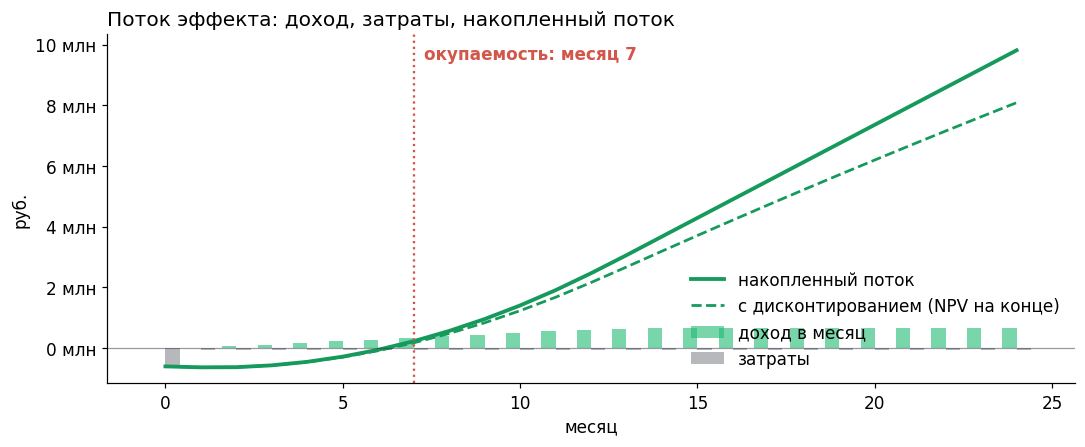

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(f.index - 0.2, f['доход'], width=0.4, color=ЗЕЛ, alpha=.6, label='доход в месяц')
ax.bar(f.index + 0.2, -f['затраты'], width=0.4, color=ТЁМН, alpha=.35, label='затраты')
ax.plot(f.index, f['накопленный'], color='#159A5C', lw=2.5, label='накопленный поток')
ax.plot(f.index, f['накопленный_с_дисконтом'], color='#159A5C', lw=1.8, ls='--',
        label='с дисконтированием (NPV на конце)')
ax.axhline(0, color=ТЁМН, lw=.8, alpha=.5)
if r['окупаемость'] is not None:
    ax.axvline(r['окупаемость'], color=КРАСН, ls=':', lw=1.5)
    ax.text(r['окупаемость'] + 0.3, ax.get_ylim()[1] * .92,
            f"окупаемость: месяц {r['окупаемость']}", color=КРАСН, fontweight='bold')
ax.set_xlabel('месяц'); ax.set_ylabel('руб.')
ax.yaxis.set_major_formatter(lambda v, _: f'{v/1e6:.0f} млн')
ax.legend(frameon=False, loc='lower right')
ax.set_title('Поток эффекта: доход, затраты, накопленный поток', loc='left')
plt.tight_layout(); plt.show()

## 4. Проверка чувствительности

Каждое допущение по очереди ставится в пессимистичное и оптимистичное
значение при базовых остальных. Вопрос проверки один: меняется ли вывод —
знак NPV, — а не на сколько меняется число. Допущение, при пессимистичном
значении которого NPV становится отрицательным, подтверждается данными
в первую очередь.

In [7]:
база = r['NPV']
строки = []
for ключ, имя, б, пес, опт in допущения:
    q = dict(параметры); q[ключ] = пес; npv_p = итоги(q)['NPV']
    q = dict(параметры); q[ключ] = опт; npv_o = итоги(q)['NPV']
    строки.append(dict(допущение=имя, базовое=б, пессимистичное=пес, NPV_пес=npv_p,
                       оптимистичное=опт, NPV_опт=npv_o,
                       вывод='меняется' if (npv_p < 0) != (база < 0) else 'сохраняется',
                       размах=abs(npv_o - npv_p)))
s = pd.DataFrame(строки).sort_values('размах', ascending=False).reset_index(drop=True)
s.round(0)

,допущение,базовое,пессимистичное,NPV_пес,оптимистичное,NPV_опт,вывод,размах
0,Предотвращённых закрытий в месяц,100.0,35,1764084.0,130,11005898.0,сохраняется,9241813.0
1,"Срок сохранения счёта, мес.",12.0,4,2424204.0,18,10321831.0,сохраняется,7897627.0
2,"Маржа на счёт в месяц, руб.",553.0,400,5395896.0,650,9793828.0,сохраняется,4397931.0
3,"Ежемесячные затраты, руб.",50000.0,80000,7462954.0,35000,8399668.0,сохраняется,936715.0
4,"Единовременные затраты, руб.",600000.0,900000,7787430.0,450000,8237430.0,сохраняется,450000.0


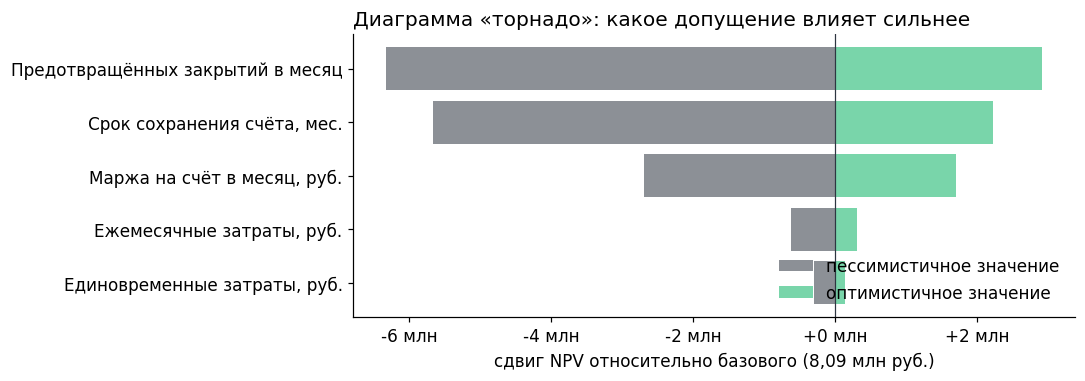

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.6))
y = np.arange(len(s))[::-1]
ax.barh(y, s['NPV_пес'] - база, color=[КРАСН if v == 'меняется' else ТЁМН for v in s['вывод']],
        alpha=.55, label='пессимистичное значение')
ax.barh(y, s['NPV_опт'] - база, color=ЗЕЛ, alpha=.6, label='оптимистичное значение')
ax.axvline(0, color=ТЁМН, lw=.8)
ax.set_yticks(y); ax.set_yticklabels(s['допущение'])
ax.xaxis.set_major_formatter(lambda v, _: f'{v/1e6:+.0f} млн')
ax.set_xlabel(f'сдвиг NPV относительно базового ({руб(база)})')
ax.legend(frameon=False, loc='lower right')
ax.set_title('Диаграмма «торнадо»: какое допущение влияет сильнее', loc='left')
plt.tight_layout(); plt.show()

## 5. Сценарии

Проверка «по одному» отвечает, какое допущение уточнять первым. Сценарий
меняет несколько допущений вместе и отвечает на вопрос о диапазоне исхода.
Пессимистичный сценарий — все допущения в пессимистичном значении
одновременно.

In [9]:
сценарии = {}
for название, поле in (('Пессимистичный', 3), ('Базовый', 2), ('Оптимистичный', 4)):
    q = dict(параметры)
    for a in допущения:
        q[a[0]] = a[поле]
    it = итоги(q)
    сценарии[название] = dict(доход_год1=it['доход_год1'], окупаемость=it['окупаемость'], NPV=it['NPV'])
сц = pd.DataFrame(сценарии).T
сц['доход_год1'] = сц['доход_год1'].map(руб); сц['NPV'] = сц['NPV'].map(руб)
сц

,доход_год1,окупаемость,NPV
Пессимистичный,532 тыс. руб.,NaN,"-1,54 млн руб."
Базовый,"3,67 млн руб.",7.0,"8,09 млн руб."
Оптимистичный,"5,61 млн руб.",5.0,"17,10 млн руб."


## 6. Слайд «Эффект для бизнеса»

Итог в виде, который переносится на последний слайд презентации проекта.

In [10]:
крит = s[s['вывод'] == 'меняется']['допущение'].tolist()
print(f'''ЭФФЕКТ ДЛЯ БИЗНЕСА · Накопительный счёт: удержание закрываемых счетов

Формула: {delta:.0f} предотвращённых закрытий в месяц × {P:,.0f} руб. маржи на счёт в месяц
         = {руб(delta * P)} в месяц на каждую месячную когорту удержанных счетов.
Выход на уровень: {параметры['ramp']} мес.; срок сохранения счёта: {параметры['keep']} мес.; горизонт: {параметры['horizon']} мес.
Затраты: единовременно {руб(параметры['capex'])}, ежемесячно {руб(параметры['opex'])}
Доход за первый год: {руб(r['доход_год1'])}; окупаемость: месяц {r['окупаемость']}
NPV за горизонт при ставке {параметры['rate']:.0%}: {руб(r['NPV'])}
Пессимистичный сценарий: NPV {руб(сценарии['Пессимистичный']['NPV'])}

Допущение, на котором вывод меняется: {', '.join(крит) if крит else 'ни одно по отдельности'}.
Самое влиятельное: {s.loc[0, 'допущение']} — подтверждается данными в первую очередь.''')

ЭФФЕКТ ДЛЯ БИЗНЕСА · Накопительный счёт: удержание закрываемых счетов

Формула: 100 предотвращённых закрытий в месяц × 553 руб. маржи на счёт в месяц
         = 55 тыс. руб. в месяц на каждую месячную когорту удержанных счетов.
Выход на уровень: 3 мес.; срок сохранения счёта: 12 мес.; горизонт: 24 мес.
Затраты: единовременно 600 тыс. руб., ежемесячно 50 тыс. руб.
Доход за первый год: 3,67 млн руб.; окупаемость: месяц 7
NPV за горизонт при ставке 15%: 8,09 млн руб.
Пессимистичный сценарий: NPV -1,54 млн руб.

Допущение, на котором вывод меняется: ни одно по отдельности.
Самое влиятельное: Предотвращённых закрытий в месяц — подтверждается данными в первую очередь.


## Что перенести на свой проект

1. Множители, которые есть в выгрузке, считаются из неё (раздел 1);
   остальные — допущения с диапазонами (раздел 2).
2. Поток строится по тем же формулам: тип эффекта, выход на уровень,
   срок сохранения, затраты (раздел 3).
3. Проверка чувствительности и сценарии — до защиты проекта, а не после
   возражений (разделы 4–5).

Тот же расчёт без кода — тренажёр «Финансовая модель эффекта»
в материалах курса; теория — страница «Финансовая модель проекта».